---   
 <img align="left" width="75" height="75"  src="https://upload.wikimedia.org/wikipedia/en/c/c8/University_of_the_Punjab_logo.png">

<h1 align="center">Department of Data Science</h1>

---
<h3><div align="right">Instructor: Muhammad Arif Butt, Ph.D.</div></h3>    

<br><br>
<h1 align="center">Lec-24: Fine-Tuning TinyLlama using <b>PEFT</b></h1>

# Learning Agenda of This Notebook

1. Install Dependencies and Check your Runtime (only in Google Colab)
2. How to Choose a Model to Fine-Tune?
3. Dataset Curation
4. **Configuration of Model, Dataset, LoRA Adapters, and Training Hyperparameters**
5. Load Base Model + Tokenizer
6. Prepare Dataset
7. **Configure and Inject LoRA Adapters**
8. **Configure Training Parameters**
9. **Train the Model (only on Google Colab)**
1. Training Loss Plot
11. Save the Adapter Weights, Push to HF and Do Inference (`arif-butt/tinyllama-peft-lora-adapter`)
12. Merge Adapter Weights, Push to HF and Do Inference (`arif-butt/tinyllama-peft-merged`)
13. Generate GGUF and Push to to HF and Do Inverence via Ollama and Llama.cpp (`arif-butt/tinyllama-peft-gguf`)



> **[Read Tim Dettmers Blog: Which GPU for Deep Learning](https://timdettmers.com/2023/01/30/which-gpu-for-deep-learning/)**

# <span style='background :lightgreen' >1. Install Dependencies and Check your Runtime (If in Google Colab)</span>

```
`transformers` | Load pretrained models and tokenizers from HuggingFace
`peft`         | Provides `LoraConfig` and `get_peft_model()` for LoRA adapter injection
`datasets`     | Load datasets from HuggingFace Hub
`accelerate`   | Enables efficient GPU training
`trl`          | Training utilities
```

In [4]:
# Uncomment following code when running in Colab
"""
!pip uninstall -y bitsandbytes 2>/dev/null || true

!pip install -q -U \
    transformers==4.41.0 \
    peft==0.11.1 \
    datasets \
    accelerate==0.30.1 \
    huggingface_hub \
    trl==0.8.6 \
    scipy \

print("All packages installed successfully!")
"""

'\n!pip uninstall -y bitsandbytes 2>/dev/null || true\n\n!pip install -q -U     transformers==4.41.0     peft==0.11.1     datasets     accelerate==0.30.1     huggingface_hub     trl==0.8.6     scipy \nprint("All packages installed successfully!")\n'

In [6]:
# For the training part of this notebook, you need a GPU, rest you can run on your laptop
# If in Colab, Go to `Runtime > Change runtime type > T4 GPU`
import torch

if torch.cuda.is_available():
    print(f"GPU  : {torch.cuda.get_device_name(0)}")
    print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No CUDA GPU detected. Running on CPU.")

No CUDA GPU detected. Running on CPU.


# <span style='background :lightgreen' >2. How to Choose a Model to Fine-Tune?</span>
# a. Commonly Used Models for Finetuning
- **Select an appropriate foundation model based on:**
    - *Model size vs compute budget:*  For learning & experimentation, models under 2B parameters are ideal as they can be fine-tuned on a single consumer GPU (even Google Colab free tier)
    - *License & deployability:*  Prefer permissive licenses (Apache 2.0, MIT) for unrestricted use
    - *Training corpus & domain bias:*  Understand what data the model was pretrained on
    - *Context length & modality support:*  Longer context = more memory; choose based on your task
    - *Instruction-tuned vs base model:*  Use instruction-tuned variants for chat/assistant tasks; base models for continued pretraining
- **Recommended Models for Students (< 2B Parameters):**
    - Below are some example models that are open-source, freely available on Hugging Face, and small enough to fine-tune on a single GPU or Google Colab.
    - If you plan to use the standard HuggingFace stack (`transformers` + `peft` + `trl`) use the original unmodified HF models
    - If you plan to use `unsloth`, you can use the NF4 4-bit version of the same model by Unsloth, so it loads instantly without a separate quantization step and is ready for QLoRA fine-tuning out of the box.
    - **TinyLlama (1.1B):** A compact LLaMA-architecture model pretrained on 3 trillion tokens and a great starting point for fine-tuning experiments. Supports 2K context length. 📄 [TinyLlama Paper](https://arxiv.org/abs/2401.02385)
        - 🔗 [TinyLlama-1.1B (Base)](https://huggingface.co/TinyLlama/TinyLlama_v1.1)
        - 🔗 [TinyLlama-1.1B-Chat (Instruction-tuned)](https://huggingface.co/TinyLlama/TinyLlama-1.1B-Chat-v1.0)
    - **Unsloth TinyLlama (1.1B):** A model optimized by Unsloth
        - 🔗 [unsloth/tinyllama](https://huggingface.co/unsloth/tinyllama)
        - 🔗 [unsloth/tinyllama-chat](https://huggingface.co/unsloth/tinyllama-chat)
        - 🔗 [unsloth/tinyllama-bnb-4bit](https://huggingface.co/unsloth/tinyllama-bnb-4bit) *(pre-quantized, ready for QLoRA)*
    - **Llama 3.2 (1B):** A Model by Meta. Supports 128K context length (far beyond TinyLlama's 2K). 📄 [LLaMA Paper](https://arxiv.org/abs/2302.13971)
        - 🔗 [meta-llama/Llama-3.2-1B (Base)](https://huggingface.co/meta-llama/Llama-3.2-1B)
        - 🔗 [meta-llama/Llama-3.2-1B-Instruct](https://huggingface.co/meta-llama/Llama-3.2-1B-Instruct)
    - **Unsloth Llama 3.2 (1B):** A Model by Meta, optimized by Unsloth.
        - 🔗 [unsloth/Llama-3.2-1B (Base)](https://huggingface.co/unsloth/Llama-3.2-1B)
        - 🔗 [unsloth/Llama-3.2-1B-Instruct](https://huggingface.co/unsloth/Llama-3.2-1B-Instruct)
        - 🔗 [unsloth/Llama-3.2-1B-Instruct-bnb-4bit](https://huggingface.co/unsloth/Llama-3.2-1B-Instruct-bnb-4bit) *(pre-quantized, ready for QLoRA)*
    - **Qwen2.5 (0.5B, 1.5B):** Models by Alibaba. Excellent for instruction-following tasks and multilingual fine-tuning. 📄 [Qwen2.5 Paper](https://arxiv.org/abs/2412.15115)
        - 🔗 [Qwen2.5-0.5B](https://huggingface.co/Qwen/Qwen2.5-0.5B)
        - 🔗 [Qwen2.5-0.5B-Instruct](https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct)
        - 🔗 [Qwen2.5-1.5B](https://huggingface.co/Qwen/Qwen2.5-1.5B)
        - 🔗 [Qwen2.5-1.5B-Instruct](https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct)
    - **Unsloth Qwen2.5 (0.5B, 1.5B):** Models by Alibaba, optimized by Unsloth
        - 🔗 [unsloth/Qwen2.5-0.5B](https://huggingface.co/unsloth/Qwen2.5-0.5B)
        - 🔗 [unsloth/Qwen2.5-0.5B-Instruct](https://huggingface.co/unsloth/Qwen2.5-0.5B-Instruct)
        - 🔗 [unsloth/Qwen2.5-0.5B-Instruct-bnb-4bit](https://huggingface.co/unsloth/Qwen2.5-0.5B-Instruct-bnb-4bit) *(pre-quantized, ready for QLoRA)*
        - 🔗 [unsloth/Qwen2.5-1.5B](https://huggingface.co/unsloth/Qwen2.5-1.5B)
        - 🔗 [unsloth/Qwen2.5-1.5B-Instruct](https://huggingface.co/unsloth/Qwen2.5-1.5B-Instruct)
        - 🔗 [unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit](https://huggingface.co/unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit) *(pre-quantized, ready for QLoRA)*
    - **Phi-1.5 (1.3B) & Phi-2 (2.7B):** By Microsoft, trained on high-quality "textbook-quality" synthetic data. Punches well above its weight class on reasoning benchmarks. 📄 [Phi-1.5 Paper](https://arxiv.org/abs/2309.05463) | 📄 [Phi-2 Blog](https://www.microsoft.com/en-us/research/blog/phi-2-the-surprising-power-of-small-language-models/)
        - 🔗 [Phi-1.5 (1.3B)](https://huggingface.co/microsoft/phi-1_5)
        - 🔗 [Phi-2 (2.7B)](https://huggingface.co/microsoft/phi-2) *(slightly above 2B but widely used)*
    - **Unsloth Phi (1.3B & 2.7B):** Models by Microsoft, optimized by Unsloth
        - 🔗 [unsloth/phi-1_5](https://huggingface.co/unsloth/phi-1_5)
        - 🔗 [unsloth/phi-2](https://huggingface.co/unsloth/phi-2)
    - **GPT-2 (117M → 1.5B):** A classic model by OpenAI for learning fine-tuning fundamentals. Not state-of-the-art but extremely well-documented with abundant tutorials. 📄 [GPT-2 Paper](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)
        - 🔗 [GPT-2 Small (117M)](https://huggingface.co/openai-community/gpt2)
        - 🔗 [GPT-2 Medium (345M)](https://huggingface.co/openai-community/gpt2-medium)
        - 🔗 [GPT-2 Large (774M)](https://huggingface.co/openai-community/gpt2-large)
        - 🔗 [GPT-2 XL (1.5B)](https://huggingface.co/openai-community/gpt2-xl)
    - **SmolLM2 (135M, 360M, 1.7B):** A family of extremely lightweight models by Hugging Face, trained on high-quality curated data (SmolLM-Corpus). Best choice for very low resource environments (even CPU). 
        - 🔗 [SmolLM2-135M](https://huggingface.co/HuggingFaceTB/SmolLM2-135M)
        - 🔗 [SmolLM2-360M](https://huggingface.co/HuggingFaceTB/SmolLM2-360M)
        - 🔗 [SmolLM2-1.7B](https://huggingface.co/HuggingFaceTB/SmolLM2-1.7B)
        - 🔗 [SmolLM2-1.7B-Instruct](https://huggingface.co/HuggingFaceTB/SmolLM2-1.7B-Instruct)
    - **OPT (125M → 1.3B):** Open Pre-trained Transformer models by Meta; good for research and learning. 📄 [OPT Paper](https://arxiv.org/abs/2205.01068)
        - 🔗 [OPT-125M](https://huggingface.co/facebook/opt-125m)
        - 🔗 [OPT-350M](https://huggingface.co/facebook/opt-350m)
        - 🔗 [OPT-1.3B](https://huggingface.co/facebook/opt-1.3b)


### Quick Comparison Table

| Model | Size | License | Instruct Version | Unsloth Version | Best For |
|---|---|---|---|---|---|
| SmolLM2 | 135M–1.7B | Apache 2.0 | ✅ Yes | ❌ Not yet | Ultra low-resource, beginners |
| TinyLlama | 1.1B | Apache 2.0 | ✅ Yes | ✅ Yes | General fine-tuning practice |
| Llama 3.2 | 1B | Llama 3.2 Community | ✅ Yes | ✅ Yes | Best capability under 2B |
| Qwen2.5 | 0.5B–1.5B | Apache 2.0 | ✅ Yes | ✅ Yes | Multilingual tasks |
| Phi-1.5 | 1.3B | MIT | ❌ Base only | ✅ Yes | Reasoning tasks |
| GPT-2 | 117M–1.5B | MIT | ❌ Base only | ❌ No | Learning fundamentals |
| OPT | 125M–1.3B | OPT-175B License | ❌ Base only | ❌ No | Research & experimentation |

# b. Choosing the Right Model Format for Fine-Tuning

- When fine-tuning on limited hardware, the **format** in which you load the model matters as much as the model you choose
- The goal is to fit the model into available VRAM while still allowing gradients to flow for training

### 📊 Quantization Formats

| Format | Description | Bits/param | Bytes/param | Size vs fp32 | Fine-tuning Support | Best For |
|---|---|---|---|---|---|---|
| **fp32** | Full precision — default floating point format | 32 | 4 | 1× (baseline) | ✅ Full fine-tune | Training on high-end hardware (24GB+ VRAM) |
| **bf16 / fp16** | Half precision — standard for modern GPU training | 16 | 2 | 2× smaller | ✅ Full / LoRA | Mixed precision training; standard fine-tuning |
| **INT8** | 8-bit integer quantization via BitsAndBytes | 8 | 1 | 4× smaller | ⚠️ Limited | Inference; light fine-tuning on GPU |
| **NF4 (bnb-4bit)** | 4-bit Normal Float by Hugging Face BitsAndBytes — load original model and quantize on-the-fly or use pre-quantized `bnb-4bit` models from Unsloth | 4 | 0.5 | 8× smaller | ✅ QLoRA (Recommended) | Fine-tuning on small GPUs & free Colab T4 |
| **GPTQ** | GPU-optimized static 4-bit quantization — possible with `auto-gptq` + `peft` but less stable for training | 4 | 0.5 | 8× smaller | ⚠️ Not recommended | Optimized for inference speed; avoid for fine-tuning |
| **AWQ** | Activation-Aware Weight Quantization — better quality than GPTQ at 4-bit but very limited training support | 4 | 0.5 | 8× smaller | ⚠️ Not recommended | Optimized for inference speed; avoid for fine-tuning |
| **GGUF** | CPU+GPU hybrid format for `llama.cpp` and `Ollama` — gradients cannot flow through GGUF weights so fine-tuning is impossible | varies | varies | varies | ❌ Never | Local CPU/laptop inference only |

> ⚠️ **Key Rule for Fine-Tuning:** Always use **BitsAndBytes NF4 (4-bit)** — it is the only format fully supported by `peft` + `trl` for QLoRA training.

### 🔗 Ready-to-Use Pre-quantized Models (BitsAndBytes NF4 — Fine-tuning Compatible)
- These models are uploaded to Hugging Face **already quantized in BitsAndBytes NF4 format** and can be loaded directly without any additional quantization step. They are fully compatible with `peft` and `trl` for QLoRA fine-tuning.
- Models are organized by family and size — **smaller models (< 2B)** are ideal for students on free Colab, while **larger models (7B–70B+)** require more VRAM or paid compute
#### 🦙 Llama 3.2 (1B, 3B) — by Meta, optimized by Unsloth
> ✅ Best choice for students — small, capable, 128K context, runs on free Colab T4
- 🔗 [unsloth/Llama-3.2-1B-bnb-4bit](https://huggingface.co/unsloth/Llama-3.2-1B-bnb-4bit) *(1B base, 4-bit)*
- 🔗 [unsloth/Llama-3.2-1B-Instruct-bnb-4bit](https://huggingface.co/unsloth/Llama-3.2-1B-Instruct-bnb-4bit) *(1B instruct, 4-bit)*
- 🔗 [unsloth/Llama-3.2-3B-bnb-4bit](https://huggingface.co/unsloth/Llama-3.2-3B-bnb-4bit) *(3B base, 4-bit)*
- 🔗 [unsloth/Llama-3.2-3B-Instruct-bnb-4bit](https://huggingface.co/unsloth/Llama-3.2-3B-Instruct-bnb-4bit) *(3B instruct, 4-bit)*
#### 🦙 Llama 3.1 (8B, 70B, 405B) — by Meta, optimized by Unsloth
> ⚠️ 8B fits on free Colab T4 with QLoRA — 70B and 405B require high-end GPUs or multi-GPU setups
- 🔗 [unsloth/Meta-Llama-3.1-8B-bnb-4bit](https://huggingface.co/unsloth/Meta-Llama-3.1-8B-bnb-4bit) *(8B base, 4-bit, 2× faster)*
- 🔗 [unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit](https://huggingface.co/unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit) *(8B instruct, chat-tuned)*
- 🔗 [unsloth/Meta-Llama-3.1-70B-bnb-4bit](https://huggingface.co/unsloth/Meta-Llama-3.1-70B-bnb-4bit) *(70B base, 4-bit — requires 40GB+ VRAM)*
- 🔗 [unsloth/Meta-Llama-3.1-405B-bnb-4bit](https://huggingface.co/unsloth/Meta-Llama-3.1-405B-bnb-4bit) *(405B base, 4-bit — requires multi-GPU)*
#### 🦙 Llama 3.3 (70B) — by Meta, optimized by Unsloth
> ⚠️ Latest and most capable Llama model — requires high-end GPU (40GB+ VRAM)
- 🔗 [unsloth/Llama-3.3-70B-Instruct-bnb-4bit](https://huggingface.co/unsloth/Llama-3.3-70B-Instruct-bnb-4bit) *(70B instruct, 4-bit)*
#### 🌬️ Mistral (7B, 22B) — by Mistral AI, optimized by Unsloth
> ✅ Mistral 7B fits on free Colab T4 — strong performance, widely used for fine-tuning
- 🔗 [unsloth/mistral-7b-instruct-v0.3-bnb-4bit](https://huggingface.co/unsloth/mistral-7b-instruct-v0.3-bnb-4bit) *(7B instruct, 4-bit)*
- 🔗 [unsloth/Mistral-Small-Instruct-2409](https://huggingface.co/unsloth/Mistral-Small-Instruct-2409) *(22B-class instruct, optimized — requires 16GB+ VRAM)*
#### 🟣 Phi (3.5 mini, 3 medium) — by Microsoft, optimized by Unsloth
> ✅ Phi-3.5-mini is ideal for students — fast, small, strong reasoning ability
- 🔗 [unsloth/Phi-3.5-mini-instruct](https://huggingface.co/unsloth/Phi-3.5-mini-instruct) *(3.8B instruct, fast and small)*
- 🔗 [unsloth/Phi-3-medium-4k-instruct](https://huggingface.co/unsloth/Phi-3-medium-4k-instruct) *(14B instruct, 4K context — requires 16GB+ VRAM)*
#### 💎 Gemma 2 (9B, 27B) — by Google, optimized by Unsloth
> ⚠️ Gemma 2 9B requires ~10GB VRAM in 4-bit — fits on Colab Pro; 27B needs 24GB+ VRAM
- 🔗 [unsloth/gemma-2-9b-bnb-4bit](https://huggingface.co/unsloth/gemma-2-9b-bnb-4bit) *(9B base, 4-bit)*
- 🔗 [unsloth/gemma-2-27b-bnb-4bit](https://huggingface.co/unsloth/gemma-2-27b-bnb-4bit) *(27B base, 4-bit — requires 24GB+ VRAM)*
#### 🔵 Qwen 2.5 (0.5B, 1.5B) — by Alibaba, optimized by Unsloth
> ✅ Excellent multilingual capability — 0.5B and 1.5B run easily on free Colab T4
- 🔗 [unsloth/Qwen2.5-0.5B-Instruct-bnb-4bit](https://huggingface.co/unsloth/Qwen2.5-0.5B-Instruct-bnb-4bit) *(0.5B instruct, 4-bit)*
- 🔗 [unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit](https://huggingface.co/unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit) *(1.5B instruct, 4-bit)*
#### 🟠 TinyLlama (1.1B) — by TinyLlama team, optimized by Unsloth
> ✅ Lightest option — fits anywhere, ideal for very first fine-tuning experiments
- 🔗 [unsloth/tinyllama-bnb-4bit](https://huggingface.co/unsloth/tinyllama-bnb-4bit) *(1.1B base, 4-bit)*

### Hardware Decision Guide
```
Do you have a GPU?
│
├── ❌ NO (CPU only)
│     └── Load in bf16 → inference only (fine-tuning not feasible on CPU)
│         Recommended: Use GGUF + Ollama for local inference instead
│
└── ✅ YES (GPU available)
      │
      ├── 🆓 Free Colab T4 (15GB VRAM)
      │     └── ✅ QLoRA — load original model + BitsAndBytes NF4 4-bit on-the-fly
      │         Best model choice: unsloth/Llama-3.2-1B-Instruct-bnb-4bit
      │         or: unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit
      │
      ├── 💻 GPU with 8–16GB VRAM (e.g., RTX 3080, RTX 4080)
      │     └── ✅ QLoRA (4-bit) or LoRA (8-bit) fine-tuning
      │         Can handle models up to ~7B with 4-bit quantization
      │
      └── 🖥️ GPU with 24GB+ VRAM (e.g., RTX 3090, A100)
            └── ✅ Full LoRA in bf16 — no quantization needed
                Can handle models up to ~13B with LoRA
```

### Recommended Workflow for Fine-Tuning
- The **most stable and widely supported** approach for fine-tuning on limited hardware is:
    - Start with the original fp32/bf16 model on Hugging Face. (Or use a pre-quantized `bnb-4bit` model from Unsloth for speed and convenience, and skip next step)
    - Load it with BitsAndBytes 4-bit quantization on-the-fly
    - Apply LoRA adapters on top via peft
    - Fine-tune using trl (SFTTrainer / DPOTrainer)
    - After training, merge LoRA weights back into base model
    - Optionally convert to GGUF for local CPU inference

### 💡 Points to Keep in Mind
> - **Starting from scratch on free Colab?** → Use **`unsloth/Llama-3.2-1B-Instruct-bnb-4bit`** — best capability, already quantized, fastest fine-tuning with Unsloth
> - **Ultra-lightweight / CPU only?** → Use **SmolLM2-1.7B** or **TinyLlama** for inference; download GGUF via [Ollama](https://ollama.com)
> - **Want to learn quantization from scratch?** → Load the original `meta-llama/Llama-3.2-1B` and apply `BitsAndBytesConfig` manually — great learning exercise
> - **Best quality under 2B?** → **`Qwen2.5-1.5B-Instruct`** or **`Llama-3.2-1B-Instruct`** consistently top small model benchmarks
> - **Using Unsloth?** → Always prefer the `bnb-4bit` Unsloth variants — they load faster and use less memory than quantizing on-the-fly

# <span style='background :lightgreen' >3. Dataset Curation</span>
- The dataset used for fine-tuning is a **custom synthetic Q&A dataset** built around **Dr. Muhammad Arif Butt** — covering his academic background, teaching experience, research interests, contact information and YouTube channel — curated specifically to teach the model to answer questions about him accurately and naturally.
## How the Dataset Was Curated
The dataset was created following a six-step curation pipeline — the same pipeline students can follow to build their own domain-specific datasets:
- **Step 1 — Collection:** Raw facts were gathered from Dr. Arif Butt's official website (https://arifbutt.me) and YouTube channel — covering all relevant topics including academic position, qualifications, research interests, courses taught and contact details
- **Step 2 — AI-Assisted Q&A Generation:** Each collected fact was fed into an AI model with a prompt instructing it to generate **3 to 5 different question variations per fact** — this rephrasing improves model generalisation by teaching it to answer the same fact regardless of how the question is phrased:
```
Fact: "Dr. Arif Butt is an Assistant Professor at PUCIT"

Generated question variations:
  "Who is Dr. Muhammad Arif Butt?"
  "Tell me about Dr. Arif Butt"
  "What is Arif Butt's current position?"
  "Where does Dr. Muhammad Arif Butt work?"
  "Which university does Dr. Arif Butt teach at?"
```
- **Step 3 — Cleaning and Validation:** All generated Q&A pairs were reviewed to remove duplicates, fix factual inaccuracies, ensure consistent tone and style, and discard any incomplete or low quality examples — human review of every example is critical at this stage since AI-generated data can contain subtle errors
- **Step 4 — Formatting:** Each Q&A pair was structured into the **ChatML messages format** required by TinyLlama — this is not optional — the model was pre-trained on this exact format and will only respond correctly if fine-tuning data matches it:
```json
{
  "messages": [
    {"role": "user",      "content": "Who is Dr. Muhammad Arif Butt?"},
    {"role": "assistant", "content": "Dr. Muhammad Arif Butt is an Assistant Professor
                                      at the Department of Data Science,
                                      University of the Punjab..."}
  ]
}
```
- **Step 5 — Balancing:** Questions were distributed evenly across all topics — academic background, teaching experience, research interests, contact information and YouTube channel — preventing the model from becoming biased toward one topic while forgetting others
- **Step 6 — Upload to HuggingFace Hub:** The final cleaned and formatted dataset was saved as `.jsonl` and uploaded as a public dataset so it can be loaded in one line anywhere:

#### 🔗 **Dataset:** [arif-butt/arifbutt_dataset](https://huggingface.co/datasets/arif-butt/arifbutt_dataset)


## Students should build their own synthetic Dataset
- Pick any domain, a product, a company or a public figure.
- Collect facts from public sources;  websites, Wikipedia, official pages.
- Feed the facts into an AI model and ask it to generate 3 to 5 question variations per fact.
- Review and clean all generated pairs, remove duplicates and fix any inaccuracies.
- Format each pair as ChatML `messages` and save as `.jsonl`.
- Upload to HuggingFace Hub using `dataset.push_to_hub()` and your dataset is ready to use.

# <span style='background :lightgreen' >4. Configuration of Model, Dataset, LoRA Adapters, and Training Hyperparameters</span>
- The code cell below defines the base model, dataset source, output directories, LoRA configuration, and training hyperparameters required for fine-tuning.
- It centralizes all experiment settings such as batch size, learning rate, and sequence length to make the training pipeline easy to configure and reproduce.
- Finally, it creates the required output directories for saving LoRA adapters and the merged final model.

In [3]:
import os

# ── Model & Dataset ───────────────────────────────────────────────────────────
BASE_MODEL_ID  = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"   # pre-trained base model to fine-tune — downloaded from HuggingFace Hub
DATASET_ID     = "arif-butt/arifbutt_dataset"           # HuggingFace dataset ID used for fine-tuning — downloaded from HuggingFace Hub

# ── Output Paths ──────────────────────────────────────────────────────────────
ADAPTER_OUTPUT_DIR = "./tinyllama-peft-lora-adapters"  # directory where LoRA adapter weights are saved during and after training — does NOT contain base model weights
MERGED_OUTPUT_DIR  = "./tinyllama-peft-merged"         # directory where the final merged model is saved — base model weights + LoRA adapter weights combined into one

# ── LoRA Hyperparameters ──────────────────────────────────────────────────────
LORA_R       = 16      # rank of the LoRA adapter matrices A and B — controls how many trainable parameters are added
                       # ΔW = B×A where B is (d×r) and A is (r×d) — lower rank = fewer params = faster but less expressive
                       # typical values: 8, 16, 32, 64 — r=16 is a good balance between capacity and efficiency

LORA_ALPHA   = 32      # scaling factor applied to the LoRA update: ΔW is multiplied by (alpha/r) before being added to frozen weights
                       # always set to 2× rank (32 = 2×16) — this keeps the effective update magnitude stable as rank changes
                       # higher alpha = larger influence of adapter updates on the frozen base model

LORA_DROPOUT = 0.05    # dropout probability applied to LoRA adapter layers during training to prevent overfitting
                       # randomly zeroes 5% of adapter activations per forward pass — set to 0.0 for very small datasets

# ── Training Hyperparameters ──────────────────────────────────────────────────
NUM_EPOCHS     = 4     # number of complete passes through the entire training dataset
                       # each epoch the model sees every training sample exactly once and updates weights accordingly

BATCH_SIZE     = 4     # number of training samples processed in one forward + backward pass per GPU
                       # larger batch = more stable gradients but higher GPU memory usage

GRAD_ACCUM     = 4     # number of batches to accumulate gradients over before performing one weight update
                       # effective batch size = BATCH_SIZE × GRAD_ACCUM = 4 × 4 = 16 samples per weight update
                       # simulates a larger batch size without requiring more GPU memory

LEARNING_RATE  = 2e-4  # step size used by the optimizer to update LoRA adapter weights after each gradient computation
                       # 2e-4 is the standard recommended learning rate for LoRA fine-tuning with Adam optimizer
                       # too large → unstable training, too small → very slow convergence

MAX_SEQ_LENGTH = 512   # maximum number of tokens allowed per training sample — sequences longer than this are truncated
                       # sequences shorter than this are padded — directly controls GPU memory usage per sample

WARMUP_RATIO   = 0.03  # fraction of total training steps used for learning rate warmup
                       # lr gradually increases from 0 to LEARNING_RATE over first 3% of steps
                       # prevents large unstable updates at the very beginning of training when weights are far from optimal

SAVE_STEPS     = 50    # save a checkpoint of the adapter weights to ADAPTER_OUTPUT_DIR every 50 training steps
                       # allows resuming training from a checkpoint if training is interrupted

LOGGING_STEPS  = 10    # log training metrics (loss, learning rate, grad norm) to console and W&B every 10 steps
                       # more frequent logging gives finer visibility into training progress but adds minor overhead

SEED           = 42    # fixed random seed for weight initialization, data shuffling and dropout
                       # ensures identical results every run for reproducibility

# ── Create Output Directories ─────────────────────────────────────────────────
os.makedirs(ADAPTER_OUTPUT_DIR, exist_ok=True)  # create adapter output directory if it does not already exist. exist_ok=True prevents error if directory already exists
os.makedirs(MERGED_OUTPUT_DIR,  exist_ok=True)  # create merged model output directory if it does not already exist

# <span style='background :lightgreen' >5. Load Base Model + Tokenizer</span>

In [4]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

print(f"Downloading base model: {BASE_MODEL_ID} ...")
model = AutoModelForCausalLM.from_pretrained(
                                            BASE_MODEL_ID,
                                            torch_dtype=torch.float16,
                                            device_map="auto",
                                            trust_remote_code=True,
)

model.config.use_cache = False         # disable KV cache during training — KV cache is only useful during inference for faster generation, not needed and wastes memory during training
model.config.pretraining_tp = 1       # disable tensor parallelism used during pre-training — set to 1 means no tensor splitting across GPUs, required for correct gradient computation during fine-tuning

print(f"Downloading tokenizer ...")
tokenizer = AutoTokenizer.from_pretrained(
                                        BASE_MODEL_ID,
                                        trust_remote_code=True,
                                        )



tokenizer.pad_token    = tokenizer.eos_token  # use the end-of-sequence token as the padding token — TinyLlama has no dedicated pad token so EOS is reused to fill shorter sequences to MAX_SEQ_LENGTH
tokenizer.padding_side = "right"              # add padding tokens to the RIGHT side of sequences — required for causal LMs like TinyLlama to ensure the model attends to real tokens before padding


print("Model and tokenizer loaded")
print(f"  Total params: {sum(p.numel() for p in model.parameters()):,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Model and tokenizer loaded
  Total params: 1,100,048,384


# <span style='background :lightgreen' >6. Load Dataset</span>

In [24]:
from datasets import load_dataset
from dotenv import load_dotenv      # Imports the load_dotenv function, which loads environment variables from a .env file into your Python environment.
from huggingface_hub import login   # Imports the login() function that allows you to authenticate with the Hugging Face Hub using an access token.
import os                           # Imports Python’s built-in os module so you can access environment variables (like your HF token).

# The following login() call is only necessary if you want to access private repos, or to use private models or to push models/datasets
'''
load_dotenv('../keys/.env', override=True)
hf_token = os.getenv('HF_TOKEN')
login(token=hf_token)
'''

raw_dataset = load_dataset("arif-butt/arifbutt_dataset")
print("✓ Dataset loaded successfully!")
raw_dataset

✓ Dataset loaded successfully!


DatasetDict({
    train: Dataset({
        features: ['messages'],
        num_rows: 1926
    })
})

In [30]:
print("\nSample examples from the training split:\n")
for idx in range(5):
    sample = raw_dataset["train"][idx]
    print("\n", sample)


Sample examples from the training split:


 {'messages': [{'role': 'user', 'content': 'Who is Dr. Muhammad Arif Butt?'}, {'role': 'assistant', 'content': 'Dr. Muhammad Arif Butt is an accomplished Assistant Professor at the Department of Data Science, University of the Punjab (PU), Lahore, Pakistan. He has over 33 years of experience in teaching and management, with expertise in cybersecurity, operating systems, and artificial intelligence.'}]}

 {'messages': [{'role': 'user', 'content': 'Tell me about Dr. Arif Butt'}, {'role': 'assistant', 'content': "Dr. Muhammad Arif Butt is an Assistant Professor at Punjab University's Data Science department. He's a technology entrepreneur and cybersecurity expert with 33+ years of experience, combining academic excellence with industry innovation."}]}

 {'messages': [{'role': 'user', 'content': "What is Arif butt's current position?"}, {'role': 'assistant', 'content': 'Dr. Muhammad Arif Butt currently serves as an Assistant Professor at the Depa

## Format the [arif-butt/arifbutt_dataset](https://huggingface.co/datasets/arif-butt/arifbutt_dataset)
- The dataset uses a `messages` format — a list of `{role, content}` dicts. We must convert each example into the exact ChatML string format TinyLlama expects:

```
<|system|>
You are a helpful assistant.</s>
<|user|>
Who is Dr. Arif Butt?</s>
<|assistant|>
Dr. Muhammad Arif Butt is an Assistant Professor...</s>
```

**Steps inside `format_example()`:**
1. Detects dataset layout (messages / instruction+output / plain text)
2. Builds the correct ChatML string for each example
3. `dataset.map()` applies this to every example in the dataset

**Tokenization:**
- `labels = input_ids` — for causal LM, the model learns to predict the next token, so labels are the same as inputs
- `truncation=True` — examples longer than `MAX_SEQ_LENGTH` are cut off
- `padding="max_length"` — shorter examples are padded to the same length

In [7]:
################# CONVERT DATASET ROWS INTO TINYLLAMA CHAT FORMAT ###############################

# ── Format Function ───────────────────────────────────────────────────────────
def format_example(example):
    """Format messages into TinyLlama ChatML conversation."""
    text = "<|system|>\nYou are a helpful assistant.</s>\n"  # start every conversation with a system prompt that sets the assistant's behaviour and persona
    for msg in example["messages"]:         # iterate over each message in the conversation — each message is a dict with "role" and "content" keys
        role    = msg["role"]               # extract the role of the message sender — either "user" or "assistant"
        content = msg["content"].strip()    # extract and clean the message text — strip() removes any leading or trailing whitespace
        if role == "user":
            text += f"<|user|>\n{content}</s>\n"        # wrap user message in TinyLlama's ChatML user tags — <|user|> opens and </s> closes the turn
        elif role == "assistant":
            text += f"<|assistant|>\n{content}</s>\n"   # wrap assistant message in TinyLlama's ChatML assistant tags — model learns to generate text between these tags
    return {"formatted_text": text}   # return the fully formatted conversation as a new column called "formatted_text" that replaces the original "messages" column

# ── Tokenize Function ─────────────────────────────────────────────────────────
def tokenize(example):
    """Convert formatted text into token IDs."""
    result = tokenizer(
                    example["formatted_text"],      # pass the ChatML formatted conversation string to the tokenizer for conversion to token IDs
                    truncation=True,                # if the formatted text exceeds MAX_SEQ_LENGTH tokens — cut it off and keep only the first MAX_SEQ_LENGTH tokens
                    max_length=MAX_SEQ_LENGTH,      # set the fixed sequence length to 512 — all sequences will be either truncated or padded to exactly this length
                    padding="max_length",           # if the formatted text is shorter than MAX_SEQ_LENGTH — pad it on the right with the pad token (EOS token) to reach exactly 512 tokens
                )
    result["labels"] = result["input_ids"].copy()   # for causal language model training the labels are identical to input_ids — the model learns to predict the next token by shifting input one position right internally
    return result   # return tokenized output containing input_ids, attention_mask and labels — all of length MAX_SEQ_LENGTH

# ── Apply Formatting ──────────────────────────────────────────────────────────
formatted_dataset = raw_dataset.map(
                        format_example,                                    # apply the format_example function to every row in the dataset
                        remove_columns=raw_dataset["train"].column_names,  # drop all original columns (messages, etc.) and keep only the new "formatted_text" column
                        )

# ── Tokenize Dataset ──────────────────────────────────────────────────────────
tokenized_dataset = formatted_dataset.map(
                        tokenize,                          # apply the tokenize function to every row in the formatted dataset
                        batched=True,                      # process multiple examples at once for significantly faster tokenization
                        remove_columns=["formatted_text"], # drop the "formatted_text" string column — no longer needed after tokenization
                        )

# ── Train / Eval Split ────────────────────────────────────────────────────────
spl = tokenized_dataset["train"].train_test_split(test_size=0.1, seed=SEED)  # randomly split the tokenized training data into 90% train and 10% evaluation using fixed seed for reproducibility

train_dataset = spl["train"]  # assign the 90% split to train_dataset — used to update LoRA adapter weights during training
eval_dataset  = spl["test"]   # assign the 10% split to eval_dataset  — used to monitor loss on unseen examples during training without updating any weights

print("Dataset prepared")
print(f"Train examples:\n {train_dataset}")  # print the train dataset object showing number of examples, column names and data types
print(f"Eval examples:\n {eval_dataset}")    # print the eval  dataset object showing number of examples, column names and data types

Map:   0%|          | 0/1926 [00:00<?, ? examples/s]

Map:   0%|          | 0/1926 [00:00<?, ? examples/s]

Dataset prepared
Train examples:
 Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1733
})
Eval examples:
 Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 193
})


In [8]:
# Print fully tokenized training example that will be fed to the model during fine-tuning of TinyLlama-1.1B-Chat-v1.0.
print(train_dataset[0])

{'input_ids': [1, 529, 29989, 5205, 29989, 29958, 13, 3492, 526, 263, 8444, 20255, 29889, 2, 29871, 13, 29966, 29989, 1792, 29989, 29958, 13, 25125, 4942, 29889, 826, 361, 505, 263, 6189, 29257, 3236, 373, 670, 14711, 8242, 29973, 2, 29871, 13, 29966, 29989, 465, 22137, 29989, 29958, 13, 8241, 29892, 4942, 29889, 29610, 826, 361, 1205, 29873, 29915, 29879, 14711, 8242, 525, 29931, 799, 29876, 2973, 826, 361, 29915, 756, 263, 6189, 29257, 3236, 411, 29871, 29945, 19707, 3625, 363, 8041, 29889, 2, 29871, 13, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

> **input_ids:** 1 → start-of-sequence token, 13 → newline token, 2 → end-of-sequence or padding token (After the real text ends, the sequence is padded because we used `MAX_SEQ_LENGTH = 512` and `padding = "max_length"`

> **attention_mask:** This tensor tells the transformer which tokens to pay attention to. 1 →  real conversation tokens, 0 →  padding and transformer ignores tokens where mask = 0

> **labels:** For causal language modeling, the labels are simply input_ids. During training the model learns: `Predict token_(t+1) from token_1 ... token_t`

In [9]:
sample = train_dataset[0]
print("Decoded text:\n")
print(tokenizer.decode(sample["input_ids"]))

Decoded text:

<s> <|system|>
You are a helpful assistant.</s> 
<|user|>
Does Dr. Arif have a Machine Learning course on his YouTube channel?</s> 
<|assistant|>
Yes, Dr. Muhammad Arif Butt's YouTube channel 'Learn With Arif' has a Machine Learning course with 5 videos available for students.</s> 
</s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></

# <span style='background :lightgreen' >7. Configure and Inject LoRA Adapters</span>

In [10]:
# Import LoRA configuration class, helper function to attach adapters, and task type enum from PEFT
from peft import LoraConfig, get_peft_model, TaskType

# Create a configuration object that defines how LoRA adapters will be inserted into the model (rank, target layers etc.)
lora_config = LoraConfig(
                            r=LORA_R,                      # Rank of the low-rank adapter matrices (controls number of additional trainable parameters)
                            lora_alpha=LORA_ALPHA,         # Scaling factor applied to the LoRA update to control its influence on the base weights
                            lora_dropout=LORA_DROPOUT,     # Dropout probability applied to LoRA layers during training to reduce overfitting
                            bias="none",                   # Specifies that biases in the original model remain frozen and are not trained
                            task_type=TaskType.CAUSAL_LM,  # Indicates that the model is being fine-tuned for causal language modeling (next-token prediction)
                            target_modules=[
                                            "q_proj",      # Query projection layer inside the transformer attention block (Query — what the token is looking for)
                                            "k_proj",      # Key projection layer inside the transformer attention block (Key — what each token offers)
                                            "v_proj",      # Value projection layer inside the transformer attention block (Value — the actual content to retrieve)
                                            "o_proj",      # Output projection layer of the attention mechanism (Output — combines all attention heads)
                                            "gate_proj",   # Gating projection controls information flow in feed-forward layer
                                            "up_proj",     # First linear layer that expands hidden dimension in the feed-forward block
                                            "down_proj"    # Second linear layer that projects expanded dimension back to hidden size
                                            ],
                        )


# Inject small trainable adapter matrices into the specified layers of the base model while freezing original weights
model = get_peft_model(
                        model,        # Pretrained base model into which LoRA adapters will be inserted
                        lora_config   # Configuration specifying adapter structure and target layers
                        )

# Check as to how many parameters are trainable vs frozen
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) # Count total number of trainable parameters (i.e., LoRA adapter weights)
total = sum(p.numel() for p in model.parameters())                        # Count total number of parameters in the entire model (base model + adapters)
print("LoRA adapters injected")
print(f"  Trainable params : {trainable:,}  ({100*trainable/total:.2f}% of total)")
print(f"  Frozen params    : {total - trainable:,}")

LoRA adapters injected
  Trainable params : 12,615,680  (1.13% of total)
  Frozen params    : 1,100,048,384


In [11]:
########################## CAST to fp32 ######################################
# The base model is in float16, but LoRA adapter weights need to be in float32 for stable gradient updates
# Cast LoRA trainable parameters to float32 to avoid FP16 gradient unscaling error
for name, param in model.named_parameters():
    if param.requires_grad:
        param.data = param.data.float()

print("LoRA adapter params cast to float32")

LoRA adapter params cast to float32


# <span style='background :lightgreen' >8. Configure Training Parameters</span>
- The following code cell defines the entire training behavior for the fine-tuning process:
    - training duration
    - batch sizes
    - optimizer
    - learning rate schedule
    - checkpointing
    - evaluation
    - reproducibility
- It acts as the central configuration object for the training loop used by the Hugging Face Trainer

In [12]:
from transformers import TrainingArguments
training_args = TrainingArguments(
    output_dir=ADAPTER_OUTPUT_DIR,        # Directory where training checkpoints and logs are saved
    num_train_epochs=NUM_EPOCHS,          # Number of full passes the model makes over the entire training dataset
    per_device_train_batch_size=BATCH_SIZE,  # Number of training samples processed per GPU in each step
    per_device_eval_batch_size=BATCH_SIZE,   # Number of evaluation samples processed per GPU during validation
    gradient_accumulation_steps=GRAD_ACCUM,  # Number of steps to accumulate gradients before performing a weight update
    learning_rate=LEARNING_RATE,          # Step size used by the optimizer when updating trainable parameters
    lr_scheduler_type="cosine",           # Learning rate schedule that gradually decreases the LR using a cosine decay
    warmup_ratio=WARMUP_RATIO,            # Fraction of total training steps used to slowly increase LR at the start
    fp16=False,                           # Disables FP16 mixed precision training (used if model weights conflict)
    bf16=False,                           # Disables BF16 precision (not supported on GPUs like NVIDIA T4)
    optim="adamw_torch",                  # Optimizer used for training (AdamW with PyTorch implementation)
    logging_steps=LOGGING_STEPS,          # Number of steps between logging training metrics (loss, LR, etc.)
    save_steps=SAVE_STEPS,                # Number of training steps between saving model checkpoints
    evaluation_strategy="steps",          # Specifies that evaluation should occur periodically during training
    eval_steps=SAVE_STEPS,                # Number of steps between evaluation runs on the validation dataset
    save_total_limit=2,                   # Maximum number of checkpoints to keep (older ones are deleted)
    load_best_model_at_end=True,          # Automatically reload the checkpoint with the best evaluation metric
    metric_for_best_model="eval_loss",    # Metric used to determine which checkpoint is the best model
    report_to="none",                     # Disables external experiment tracking tools (e.g., WandB)
    seed=SEED,                            # Fixed random seed to ensure reproducible training results
    group_by_length=True,                 # Groups sequences of similar length together to reduce padding and speed up training
)

print("TrainingArguments configured")

TrainingArguments configured


/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


# <span style='background :lightgreen' >9. Train the Model (only on Google Colab)</span>
**What happens inside `trainer.train()`:**
```
For each batch:
  1. Forward pass   — feed tokens through model, get predictions
  2. Loss           — measure how wrong predictions are (cross-entropy)
  3. Backprop       — calculate gradients
  4. Update         — adjust only LoRA adapter weights
  5. Repeat
```

**How to read the training table:**
```
`Step`            | How many batches have been processed
`Training Loss`   | Loss on training data — should go down
`Validation Loss` | Loss on unseen data — should follow training loss
```
**Diagnosing your training:**
-  Both losses going down together → healthy training
-  Train loss low, eval loss rising → overfitting → reduce epochs
-  Both losses staying high → underfitting → increase epochs or LORA_R

**The estimated time to run this code cell on a Google Colab T4 GPU is approximately 32.3 minutes.You can see total steps, Train loss and Runtime in the output of this cell**

In [13]:
from transformers import Trainer, DataCollatorForLanguageModeling

# Create a data collator to handle batching and token alignment during training
data_collator = DataCollatorForLanguageModeling(
                                            tokenizer=tokenizer,  # tokenizer used to convert text to input IDs
                                            mlm=False,            # causal language modeling (next-token prediction) instead of masked LM
                                            )



# Initialize the Hugging Face Trainer to manage training loop
# Trainer connects model, datasets, tokenizer, data collator, and training arguments
trainer = Trainer(
                    model=model,                      # Model with LoRA adapters injected
                    args=training_args,               # Training configuration (epochs, LR, batch size, checkpoints, etc.)
                    train_dataset=train_dataset,      # Preprocessed & tokenized training dataset
                    eval_dataset=eval_dataset,        # Preprocessed & tokenized evaluation dataset
                    tokenizer=tokenizer,              # Tokenizer used for encoding and decoding text
                    data_collator=data_collator,      # Batches examples together during training
                )


# Start the training loop — performs forward pass, computes loss, backpropagates gradients, updates LoRA weights
print("Starting training...")
train_result = trainer.train()  # Returns a `TrainOutput` object containing metrics and state


# Training complete — print key metrics for monitoring
print("Training complete!")
print(f"  Train loss  : {train_result.training_loss:.4f}")          # Final training loss
print(f"  Total steps : {train_result.global_step}")                # Total number of optimizer steps performed
print(f"  Runtime     : {train_result.metrics.get('train_runtime', 0)/60:.1f} mins")  # Approx runtime in minutes

Starting training...


Step,Training Loss,Validation Loss
50,0.780000,0.687115
100,0.463500,0.477699
150,0.345500,0.353708
200,0.254900,0.279348
250,0.168700,0.211105
300,0.131100,0.179656
350,0.108600,0.160624
400,0.103900,0.151071


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in ver

Training complete!
  Train loss  : 0.3547
  Total steps : 432
  Runtime     : 32.0 mins


# <span style='background :lightgreen' >10. Training Loss Plot</span>
This cell plots the training and evaluation loss as a line chart so you can visually diagnose training health.

- 🔵 **Blue line** — Training loss
- 🔴 **Red dashed line** — Evaluation loss

Both lines going down smoothly and staying close together = healthy training. The plot is also saved as `training_loss.png`.

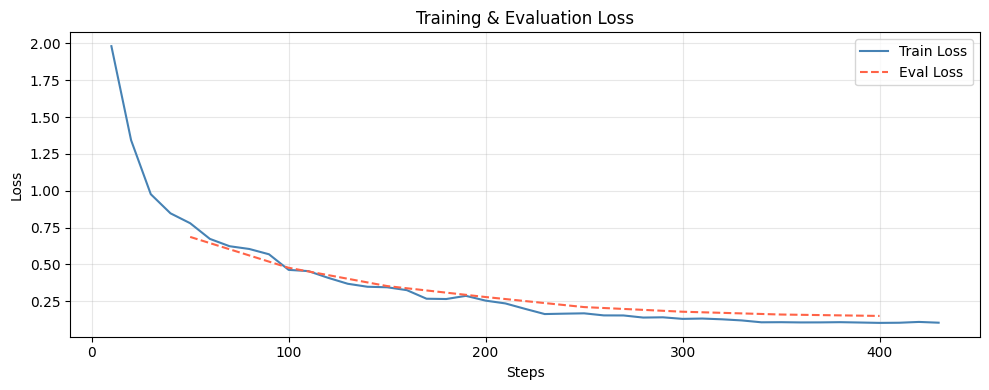

Plot saved as training_loss.png


In [14]:
import matplotlib.pyplot as plt

train_logs = [e for e in trainer.state.log_history if "loss" in e and "eval_loss" not in e]
eval_logs  = [e for e in trainer.state.log_history if "eval_loss" in e]

if train_logs:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot([e["step"] for e in train_logs], [e["loss"] for e in train_logs],
            label="Train Loss", color="steelblue")
    if eval_logs:
        ax.plot([e["step"] for e in eval_logs], [e["eval_loss"] for e in eval_logs],
                label="Eval Loss", color="tomato", linestyle="--")
    ax.set_xlabel("Steps"); ax.set_ylabel("Loss")
    ax.set_title("Training & Evaluation Loss")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("training_loss.png", dpi=150)
    plt.show()
    print("Plot saved as training_loss.png")
else:
    print("No training logs found.")

# <span style='background :lightgreen' >11. Save the Adapter Weights, Push to HF and Do Inference</span>

## a. Save the Adapter Weights
- After training we save **only the LoRA adapter weights** (48.16 MB), not the full merged model weights which will be greater than 2.2 GB.
- The saved folder contains:
    - `adapter_config.json`       — LoRA architecture definition
    - `adapter_model.safetensors` — the actual trained weights around 30 MB only
    - `tokenizer files`           — if tokenizer saved alongside adapters
- Can be pushed on hugging face hub
- The advantages of this option are:
    -  The size of files to be saved is small
    -  If pushed on HF hub, any one having TinyLlama base can download the adapter weights and use them with base model

####  After `model.save_pretrained()` and `tokenizer.save_pretrained()`, the ADAPTER_OUTPUT_DIR (`./tinyllama-peft-lora-adapters`) contains:

| File | Size | Contents |
|---|---|---|
| `adapter_model.safetensors` | 48.16 MB | The **LoRA adapter weights only** — the small delta matrices (A & B) injected into the base model layers. Does **not** contain base model weights. |
| `adapter_config.json` | 737 B | LoRA configuration: rank (`r`), alpha, dropout, target modules, task type. Needed to reconstruct the PEFT model. |
| `tokenizer.json` | 1.76 MB | Fast tokenizer data — full vocabulary, BPE merge rules, and special token mappings. |
| `tokenizer_config.json` | 1.3 KB | Tokenizer metadata — class name, special tokens (`bos_token`, `eos_token`, `pad_token`), padding side, etc. |
| `tokenizer.model` | 488.0 KB | The raw SentencePiece model file used by the slow tokenizer for subword tokenization. |
| `special_tokens_map.json` | 437 B | Maps special token names (`bos_token`, `eos_token`, `unk_token`) to their string values. |
| `checkpoint-350/` | 4.0 KB | Mid-training checkpoint saved automatically at step 350. |
| `checkpoint-400/` | 4.0 KB | Mid-training checkpoint saved automatically at step 400 (latest). |
| `README.md` | 5.0 KB | Auto-generated model card describing the adapter. |



>- **Limitation of this option is, the uploaded adapter weights cannot be used as a standalone model, for which you have to merge**

In [15]:
###################################### SAVE LORA ADAPTER WEIGHTS ONLY #############################################################
# lightweight — only saves the small adapter weights (~16 MB) but requires the base model to be loaded separately at inference time
####################################################################################################################################

model.save_pretrained(ADAPTER_OUTPUT_DIR)         # LoRA adapter weights + adapter config
tokenizer.save_pretrained(ADAPTER_OUTPUT_DIR)     # # Tokenizer files alongside the adapter

print(f"Adapter weights saved to: {ADAPTER_OUTPUT_DIR}")
print(f"Files: {os.listdir(ADAPTER_OUTPUT_DIR)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Adapter weights saved to: ./tinyllama-peft-lora-adapters
Files: ['special_tokens_map.json', 'adapter_config.json', 'checkpoint-400', 'adapter_model.safetensors', 'tokenizer.json', 'tokenizer_config.json', 'tokenizer.model', 'checkpoint-350', 'README.md']


In [17]:
import os

adapter_dir = "./tinyllama-peft-lora-adapters"

if os.path.exists(adapter_dir):
    print(f"Files saved in: {adapter_dir}\n")
    for fname in sorted(os.listdir(adapter_dir)):
        fpath = os.path.join(adapter_dir, fname)
        size  = os.path.getsize(fpath)
        if size >= 1_048_576:
            size_str = f"{size / 1_048_576:.2f} MB"
        elif size >= 1024:
            size_str = f"{size / 1024:.1f} KB"
        else:
            size_str = f"{size} B"
        print(f"  {fname:<40} {size_str}")
else:
    print(f"Directory '{adapter_dir}' not found.")
    print("Run the training and save steps first before listing files.")

Files saved in: ./tinyllama-peft-lora-adapters

  README.md                                5.0 KB
  adapter_config.json                      737 B
  adapter_model.safetensors                48.16 MB
  checkpoint-350                           4.0 KB
  checkpoint-400                           4.0 KB
  special_tokens_map.json                  437 B
  tokenizer.json                           1.76 MB
  tokenizer.model                          488.0 KB
  tokenizer_config.json                    1.3 KB


## b. Push the Files to HuggingFace Hub
After merging, push the standalone model to HuggingFace Hub so it can be loaded from anywhere without needing local files.

**Before pushing, you need a Write token:**  
Go to → **huggingface.co → Profile → Settings → Access Tokens → New Token → Type: Write**

In [19]:
import os
from huggingface_hub import HfApi, create_repo, login
from getpass import getpass

# 1. LOGIN (SECURE INPUT)
hf_token = getpass("Enter your Hugging Face API token: ")
login(token=hf_token)

# 2. SET REPO DETAILS (EDIT THIS)

#repo_id = "arif-butt/tinyllama-peft-lora-adapter" # Set your repo here

# Local directory where your adapter is saved
adapter_dir = "./tinyllama-peft-lora-adapters"

# 4. CREATE REPO (IF NOT EXISTS)
print("Creating repo (if needed)...")

create_repo(
    repo_id=repo_id,
    repo_type="model",
    exist_ok=True)

print(f"Repo ready: https://huggingface.co/{repo_id}")

# 5. UPLOAD FILES
api = HfApi()
print("Uploading adapter files...")

api.upload_folder(
    folder_path=adapter_dir,
    repo_id=repo_id,
    repo_type="model")

print("Upload complete!")

# 6. DONE
print(f"\nYour adapter is live at:")
print(f"https://huggingface.co/{repo_id}")

🔐 Enter your Hugging Face API token: ··········
📦 Creating repo (if needed)...
✅ Repo ready: https://huggingface.co/arif-butt/tinyllama-peft-lora-adapter
⬆️ Uploading adapter files...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...point-350/tokenizer.model: 100%|##########|  500kB /  500kB            

  ...-adapters/tokenizer.model: 100%|##########|  500kB /  500kB            

...

  ...ckpoint-350/rng_state.pth:   1%|1         |   162B / 14.6kB            

  ...eckpoint-350/scheduler.pt:   1%|1         |  16.0B / 1.47kB            

  ...int-350/training_args.bin:   1%|1         |  61.0B / 5.52kB            

  ...ckpoint-400/rng_state.pth:   1%|1         |   162B / 14.6kB            

✅ Upload complete!

🎉 Your adapter is live at:
👉 https://huggingface.co/arif-butt/tinyllama-peft-lora-adapter


## c. Inference with loading LoRa Adapter from hugging face

In [1]:
# This script loads a base model with pre-trained LoRA adapters directly from HuggingFace Hub
# and sets up a text generation pipeline for inference without needing to merge adapters locally

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from peft import PeftModel

# ── Model Identifiers ────────────────────────────────────────────────────────────────────────
# 🔹 Hugging Face repo names — these point to models stored on the HuggingFace Hub
BASE_MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"      # base pre-trained model — 1.1B parameter chat-optimized Llama variant
ADAPTER_REPO = "arif-butt/tinyllama-peft-lora-adapter"    # LoRA adapter weights uploaded to HuggingFace Hub — trained on custom dataset

# ── Load Base Model ──────────────────────────────────────────────────────────────────────────
# First load the original pre-trained model without any adapters
print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,                                        # identifier for base model on HuggingFace Hub
    torch_dtype=torch.float16,                            # use float16 precision — reduces memory usage by 50% with minimal quality loss
    device_map="auto"                                     # automatically distribute layers across available GPUs/CPU
)

# Load the trained LoRA adapter weights and attach them to the base model
# The adapter_config.json in the repo defines which layers to modify and with what rank
model = PeftModel.from_pretrained(
    base_model,                                           # base model to attach adapters to — original weights remain frozen
    ADAPTER_REPO                                          # HuggingFace repo containing adapter weights and config
)

print("Base model loaded and LoRA adapters attached successfully")

# Tokenizer must match the one used during training — loaded from adapter repo to ensure consistency
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    ADAPTER_REPO                                          # tokenizer config saved in same repo as adapters
)

print("Tokenizer loaded successfully")

# Pipeline simplifies inference by handling tokenization, model generation, and decoding automatically
# This creates a ready-to-use interface for generating text with the fine-tuned model
pipe = pipeline(
    "text-generation",                                    # task type — generates text conditioned on input prompt
    model=model,                                          # fine-tuned model with LoRA adapters attached
    tokenizer=tokenizer                                   # tokenizer that matches the model's vocabulary
)

print("Text generation pipeline created")
print(f"Model loaded from: {BASE_MODEL_ID} + {ADAPTER_REPO}")
print(f"Model device: {model.device}")
print(f"Total parameters: {model.num_parameters():,}")


Loading base model...


`torch_dtype` is deprecated! Use `dtype` instead!


Base model loaded and LoRA adapters attached successfully
Loading tokenizer...


You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama_fast.LlamaTokenizerFast'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565 - if you loaded a llama tokenizer from a GGUF file you can ignore this message.
Device set to use mps


Tokenizer loaded successfully
Text generation pipeline created
Model loaded from: TinyLlama/TinyLlama-1.1B-Chat-v1.0 + arif-butt/tinyllama-peft-lora-adapter
Model device: mps:0
Total parameters: 1,112,664,064


In [2]:
# Test prompt
prompt = "Q: Name all the courses Arif butt teach?\nA:"
output = pipe(prompt, max_new_tokens=100, temperature=0.2)
print(output[0]["generated_text"])

Q: Name all the courses Arif butt teach?
A: Arif butt teaches Information Security, Cybersecurity, Network Penetration Testing, Android App Development, and System Programming at the University of the Punjab.


### Before merging, we free up VRAM by deleting the trainer and model from memory. This prevents Out-of-Memory errors when reloading the base model for merging.

In [ ]:
import gc
import torch

del trainer
del model
gc.collect()
torch.cuda.empty_cache()

print("GPU memory cleared!")
if torch.cuda.is_available():
    print(f"Allocated : {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    print(f"Reserved  : {torch.cuda.memory_reserved() / 1e9:.2f} GB")

# <span style='background :lightgreen' >12. Merge Adapter Weights, Push to HF and Do Inference</span>

## a. Save the Complete Merged  Model
- Now that we have saved the adapter weights, we can now create the final standalone model by merging the LoRA adapters into the base model.
- Before merge → need both base model + adapter files to run
- After merge → one single file, no PEFT library needed at inference time
- **What Gets Saved After Both Steps:**
```
./tinyllama-peft-lora-adapters/              ← ADAPTER_OUTPUT_DIR
  ├── adapter_config.json               ← LoRA config (r=16, alpha=32, target modules)
  ├── adapter_model.safetensors         ← LoRA adapter weights only (~16 MB)
  ├── tokenizer.json                    ← full tokenizer
  ├── tokenizer_config.json             ← tokenizer settings
  ├── special_tokens_map.json           ← special tokens
  └── tokenizer.model                   ← tokenizer binary

./tinyllama-peft-merged/                     ← MERGED_OUTPUT_DIR
  ├── config.json                       ← full model architecture config
  ├── generation_config.json            ← default generation settings
  ├── model.safetensors                 ← FULL merged weights (~2.2 GB)
  ├── tokenizer.json                    ← full tokenizer
  ├── tokenizer_config.json             ← tokenizer settings
  ├── special_tokens_map.json           ← special tokens
  └── tokenizer.model                   ← tokenizer binary
```

In [21]:
import torch
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer

# We need to reload the base model, because we deleted it in above code cell to free GPU memory. Now we reload it clean — no adapters attached yet.
print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)

# Putting a trained overlay on top of the original model. It reads the adapter architecture from `adapter_config.json`, loads the trained weights, and clips them onto the exact layers they were trained on.
print("Reloading base model + Attaching saved LoRA adapters...")
finetuned_model = PeftModel.from_pretrained(base_model, ADAPTER_OUTPUT_DIR)


#  During training, adapters lived separately alongside the frozen weights. Merging permanently bakes them in
print("Merging adapter weights into base model...")
finetuned_model = finetuned_model.merge_and_unload()     # Final Weight = Original Frozen Weight + (LoRA_B × LoRA_A) × scaling

MERGED_MODEL_DIR = "./tinyllama-merged-model"

print("Saving merged model...")

finetuned_model.save_pretrained(MERGED_OUTPUT_DIR)
tokenizer.save_pretrained(MERGED_OUTPUT_DIR)

print("Model saved locally!")
finetuned_model.eval()      # Switches the model from training mode to inference mode by disablING dropout (randomly switching off neurons during training to prevent overfitting). During inference you want every neuron active for consistent answers.

tokenizer = AutoTokenizer.from_pretrained(ADAPTER_OUTPUT_DIR, trust_remote_code=True)

print("Merged model ready!")

Loading base model...
Reloading base model + Attaching saved LoRA adapters...
Merging adapter weights into base model...
💾 Saving merged model...
✅ Model saved locally!
Merged model ready!


## b. Push the Merged model Files to HuggingFace Hub

After merging, push the standalone model to HuggingFace Hub so it can be loaded from anywhere without needing local files.

**Before pushing, you need a Write token:**  
Go to → **huggingface.co → Profile → Settings → Access Tokens → New Token → Type: Write**

In [22]:
import os
from huggingface_hub import HfApi, create_repo, login
from getpass import getpass

# 1. LOGIN
hf_token = getpass("Enter your Hugging Face token: ")
login(token=hf_token)

# 2. REPO CONFIG
repo_id = "arif-butt/tinyllama-peft-merged"

# 3. CHECK MODEL FOLDER
if not os.path.exists(MERGED_OUTPUT_DIR):
    raise FileNotFoundError("Merged model folder not found!")

# 4. CREATE REPO
print("Creating repo...")

create_repo(
    repo_id=repo_id,
    repo_type="model",
    exist_ok=True)

print(f"Repo ready: https://huggingface.co/{repo_id}")

# 5. UPLOAD (IMPORTANT FOR LARGE MODELS)
api = HfApi()

print("Uploading merged model (this may take time)...")

api.upload_folder(
    folder_path=MERGED_OUTPUT_DIR,
    repo_id=repo_id,
    repo_type="model"
)

print("Upload complete!")

print(f"\n🎉 Model available at:")
print(f"https://huggingface.co/{repo_id}")

🔐 Enter your Hugging Face token: ··········
📦 Creating repo...
✅ Repo ready: https://huggingface.co/arif-butt/tinyllama-peft-merged
⬆️ Uploading merged model (this may take time)...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ged-model/tokenizer.model: 100%|##########|  500kB /  500kB            

  ...d-model/model.safetensors:   2%|1         | 40.0MB / 2.20GB            

✅ Upload complete!

🎉 Model available at:
https://huggingface.co/arif-butt/tinyllama-peft-merged


## c. Inference by loading merged model from hugging face

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch

# 1. Model Repo
MERGED_MODEL_ID = "arif-butt/tinyllama-peft-merged"

# 2. Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MERGED_MODEL_ID)

# 3. Load merged model (standalone)
model = AutoModelForCausalLM.from_pretrained(
    MERGED_MODEL_ID,
    torch_dtype=torch.float16,  # use half precision for GPU efficiency
    device_map="auto"           # automatically use GPU if available
)
# 4. Create pipeline
pipe = pipeline(
    task="text-generation",
    model=model,
    tokenizer=tokenizer,
    return_full_text=False  # only return the model-generated answer
)



Device set to use mps


In [4]:
# 5. Example prompt
prompt = "Q: Who is Dr. Arif Butt?\nA:"

output = pipe(
    prompt,
    max_new_tokens=150,
    do_sample=False,           # deterministic/factual output
    repetition_penalty=1.1
)

# 6. Print answer
print(output[0]["generated_text"].strip())

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Dr. Muhammad Arif Butt is an Assistant Professor at the Department of Data Science, University of the Punjab (PU), Lahore, Pakistan. He has over 33 years of experience in teaching and management, with expertise in cybersecurity, operating systems, and artificial intelligence.


###  **Files Uploaded to HuggingFace Hub**

After pushing the merge model to hugging face, your repository on HuggingFace Hub will contain:

```
your-username/tinyllama-drarif-finetuned/
├── model.safetensors          (~2.2 GB)  — Merged model weights (base + LoRA baked in). All neural network parameters in SafeTensors format.
├── config.json                (~713 B)   — Model architecture config: type (LlamaForCausalLM), hidden size, num layers, attention heads, vocab size.
├── tokenizer.json             (~1.84 MB) — Fast tokenizer: full vocabulary, BPE merge rules, special token mappings.
├── tokenizer_config.json      (~1.32 KB) — Tokenizer settings: class, special tokens (bos/eos/pad), padding side, chat template.
├── chat_template.jinja        (~1 KB)    — Jinja2 template for ChatML prompt format (<|system|>, <|user|>, <|assistant|> with </s> endings).
├── generation_config.json     (~124 B)   — Default generation parameters (eos_token_id, bos_token_id).
└── special_tokens_map.json    (~437 B)   — Maps special token names to their string values.
```

These files are everything needed to load and run the model from any machine


# <span style='background :lightgreen' >13. Generate GGUF and Push the Files to HuggingFace Hub and do local Inference vial ollama and llama.cpp</span>
## a. Generate GGUF


- **GPT-Generated Unified Format (GGUF)** is a modern, unified model file format designed for efficient local inference, especially for *LLaMA-family* of models using tools like **llama.cpp** and **Ollama**.
    - *GGUF File Container:* The outer wrapper that holds all model components in a single binary file, eliminating the ned of multi-file setups and ensures consistency between model components.
    - *Metadata Layer:* This layer stores model configuration and descriptive information, including model architecture and dimensions, context length, special tokens (BOS, EOS, PAD) and inference-related parameters.
    - *Tokenization Layer:* This layer defines how raw text is converted into tokens.
    - *Quantization Layer:* This layer describes how weights are compressed using different quantization formats like Q4, and Q8. This enables running large models on limited hardware.
    - *Model Weights and Tensors:* This layer contains the actual neural network parameters stored as optimized tensors.





`snapshot_download()` downloads the already-merged fine-tuned model locally from HuggingFace Hub so that `llama.cpp` can access it for conversion.

`convert_hf_to_gguf.py` is a llama.cpp script that converts a HuggingFace model into GGUF format — the standard format for local inference via Ollama or llama.cpp.

`upload_file()` from `huggingface_hub` uploads the converted GGUF file back to the same HuggingFace repo so it can be downloaded and run locally.

**Why `q8_0`?**
- 8-bit quantization — almost zero accuracy loss compared to fp16
- TinyLlama Q8_0 ≈ 1.1 GB — runs easily on any laptop CPU
- Best balance of size and accuracy for a domain-specific Q&A model

| GGUF Format | Size | Accuracy |
|---|---|---|
| `q8_0` | ~1.1 GB | Almost no loss |
| `q5_k_m` | ~0.7 GB | Very small loss |
| `q4_k_m` | ~0.6 GB | Slight loss |

In [33]:
#!pip install transformers accelerate triton
#!git clone --depth=1 https://github.com/abetterinternet/gguf-loader.git
#!cd gguf-loader && pip install .

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
import os
import json
import shutil

# ─────────────────────────────
# 1. Paths
# ─────────────────────────────
GGUF_DIR = "./merge-peft-gguf"   # output GGUF folder
os.makedirs(GGUF_DIR, exist_ok=True)
GGUF_PATH = os.path.join(GGUF_DIR, "tinyllama-merged.gguf")

# ─────────────────────────────
# 2. Load merged model
# ─────────────────────────────
print("Loading merged model...")
model = AutoModelForCausalLM.from_pretrained(MERGED_OUTPUT_DIR, torch_dtype=torch.float16, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(MERGED_OUTPUT_DIR)

# ─────────────────────────────
# 3. Save as GGUF (simple FP16 dump)
# ─────────────────────────────
print("Converting to GGUF...")

# Create a minimal GGUF format (FP16 weights + tokenizer + config)
weights_path = os.path.join(GGUF_DIR, "pytorch_model.bin")
model.save_pretrained(GGUF_DIR)         # save model weights
tokenizer.save_pretrained(GGUF_DIR)     # save tokenizer
shutil.copyfile(os.path.join(GGUF_DIR, "pytorch_model.bin"), GGUF_PATH)

# Save a minimal config.json for GGUF reference
config = {
    "model_type": "causal_lm",
    "dtype": "fp16",
    "name": "tinyllama-merged"
}
with open(os.path.join(GGUF_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=4)

print("✅ GGUF conversion done!")
print("Files in GGUF folder:", os.listdir(GGUF_DIR))

## b. Push GGUF file on Hugging Face Hub

In [ ]:
import os
from huggingface_hub import HfApi, create_repo, upload_folder
from getpass import getpass

# ─────────────────────────────
# 1. USER INPUT
# ─────────────────────────────
hf_token = getpass("Enter your Hugging Face API token: ")
repo_id = input("Enter Hugging Face repo name (username/repo-name): ").strip()  # e.g., arif-butt/tinyllama-merged-gguf

# Local folder containing GGUF
GGUF_DIR = "./merge-peft-gguf"

# ─────────────────────────────
# 2. CREATE REPO (if it doesn't exist)
# ─────────────────────────────
api = HfApi()
try:
    create_repo(repo_id=repo_id, token=hf_token, exist_ok=True)
    print(f"Repo created / already exists: {repo_id}")
except Exception as e:
    print("Repo creation failed:", e)

# ─────────────────────────────
# 3. PUSH GGUF folder
# ─────────────────────────────
print(f"Uploading '{GGUF_DIR}' to Hugging Face...")
upload_folder(
    folder_path=GGUF_DIR,
    repo_id=repo_id,
    token=hf_token,
    ignore_patterns=["*.pyc", "__pycache__"]
)

print(f"GGUF model successfully uploaded to HF: https://huggingface.co/{repo_id}")

## c. Inference by using GGUF from Hugging Face Hub using Ollama or llama.cpp
<h1 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">Ollama lets you download models from Ollama Hub or the Hugging Face Hub.</h1>

### Step 1: Download and Install Ollama
- Download Ollama for your Mac, Linux or Windows machine by visiting: https://ollama.com/download
- To check if ollama has been installed on your machine, open a terminal and give the command `ollama`:
```
Available Commands:
  serve       Start ollama
  create      Create a model
  show        Show information for a model
  run         Run a model
  stop        Stop a running model
  pull        Pull a model from a registry
  push        Push a model to a registry
  signin      Sign in to ollama.com
  signout     Sign out from ollama.com
  list        List models
  ps          List running models
  cp          Copy a model
  rm          Remove a model
  launch      Launch an integration with Ollama
  help        Help about any command
Use "ollama [command] --help" for more information about a specific command.
```
- To ensure Ollama application is running in the background, just open a browser and go to http://localhost:11434/ and it will display a message saying **"ollama is running"**. If this is not the case, then on the terminal give the command `ollama serve` and try again :)

### Step 2: Download the GGUF version of your Fine-Tuned model
- Ollama only runs models in the GGUF format because it is built on llama.cpp which reads GGUF files for efficient inference
- Go to **https://huggingface.co/arif-butt/tinyllama-peft-gguf**, click ‘Files and Versions’ on the model page, and then click the Download button on **https://huggingface.co/arif-butt/tinyllama-peft-gguf/blob/main/tinyllama-peft_q8.gguf** to download the model on your local machine
- I have downloaded the model inside the `../models/tinyllama-peft-gguf/` directory.


### Step 3: Create a Modelfile
- A **Modelfile** in Ollama is a small text configuration file that tells Ollama how to use a specific model.
- Think of it as a bridge between the GGUF model file and Ollama’s chat interface, it defines which model to load and how the conversation should behave.
- **Why is it needed?** Ollama itself cannot automatically know:
  - Which GGUF model to load.
  - How to handle prompts, messages, and system instructions.
  - What generation parameters to use (temperature, top-p, etc.).
- The Modelfile encapsulates all this information so you can run your model with consistent behavior.
- It makes customizing models easier without modifying the GGUF file itself.
- Create a file named `Modelfile` (no extension) in `C:\Models\` with this content:
```
FROM /Users/arif/Documents/genai-course/models/tinyllama-peft-gguf/tinyllama-peft_q8.gguf
SYSTEM """You are a helpful assistant."""

TEMPLATE """<|system|>
{{ .System }}</s>
<|user|>
{{ .Prompt }}</s>
<|assistant|>
"""

PARAMETER stop "<|system|>"
PARAMETER stop "<|user|>"
PARAMETER stop "<|assistant|>"
PARAMETER stop "</s>"
PARAMETER temperature 0.7
PARAMETER num_ctx 256
```

In [14]:
!cat ../models/tinyllama-peft-gguf/Modelfile

FROM /Users/arif/Documents/genai-course/models/tinyllama-peft-gguf/tinyllama-peft_q8.gguf
SYSTEM """You are a helpful assistant."""

TEMPLATE """<|system|>
{{ .System }}</s>
<|user|>
{{ .Prompt }}</s>
<|assistant|>
"""

PARAMETER stop "<|system|>"
PARAMETER stop "<|user|>"
PARAMETER stop "<|assistant|>"
PARAMETER stop "</s>"
PARAMETER temperature 0.7
PARAMETER num_ctx 256

### Step 4 — Build the model using ollama create
- Use the `ollama create` command which will do the following tasks:
    - Copy your local GGUF file into Ollama’s internal model store, verifying its SHA-256 hash.
    - Parsed the GGUF to detect model architecture and created new “layers” that include your system prompt and parameters.
    - Wrote a new manifest and registered a new Ollama model name, so you can run it like any other built-in model.
- Once done the `ollama list` command will display the new model that you can run

In [15]:
!ollama create tinyllama-ft-peft -f /Users/arif/Documents/genai-course/models/tinyllama-peft-gguf/Modelfile

]11;?\gathering model components ⠙ gathering model components ⠹ gathering model components ⠸ gathering model components ⠼ gathering model components ⠼ gathering model components ⠴ gathering model components ⠧ gathering model components 
copying file sha256:937eacc1daff2bfa7e26f166d5496ff0575f19b2acd756c3f12101d098d555d9 100% 
parsing GGUF 
using existing layer sha256:937eacc1daff2bfa7e26f166d5496ff0575f19b2acd756c3f12101d098d555d9 
using existing layer sha256:af0ddbdaaa26f30d54d727f9dd944b76bdb926fdaf9a58f63f78c532f57c191f 
using existing layer sha256:75357d685f238b6afd7738be9786fdafde641eb6ca9a3be7471939715a68a4de 
using existing layer sha256:b4d4c947e00493043ff5b14d8f90a05020b280add23a760153cead2e3e743f49 
writing manifest 
success 


In [16]:
!ollama list

]11;?\NAME                        ID              SIZE      MODIFIED      
tinyllama-ft-peft:latest    c910d9ca7c69    1.2 GB    7 seconds ago    
qwen3.5:cloud               a7bf6f7891c3    -         3 weeks ago      
qwen3-vl:235b-cloud         86b3322ec200    -         3 weeks ago      
qwen3.5:397b-cloud          a7bf6f7891c3    -         3 weeks ago      
minimax-m2.5:cloud          c0d5751c800f    -         5 weeks ago      
mygemma:latest              a631de1ab12d    1.1 GB    3 months ago     
deepseek-v3.1:671b-cloud    d3749919e45f    -         3 months ago     
gpt-oss:20b-cloud           875e8e3a629a    -         3 months ago     
gpt-oss:120b-cloud          569662207105    -         3 months ago     
qwen3-coder:480b-cloud      e30e45586389    -         3 months ago     
nomic-embed-text:latest     0a109f422b47    274 MB    3 months ago     
tinyllama:latest            2644915ede35    637 MB    3 months ago     
deepseek-r1:1.5b            e0979632db5a    1.1 GB    9 mon

### Step 5 - Run your new Model via CLI

In [2]:
!ollama run tinyllama-ft-peft "Who is Dr. Arif Butt?\n"

]11;?\Dr. Muhammad Arif Butt is an Assistant Professor at Punjab University's Dat
Data Science department. He's also a technology entrepreneur and cybersecur
cybersecurity expert with over 33 years of experience.



In [3]:
!ollama run tinyllama-ft-peft "What is the email address of Dr. Arif  Butt?"

]11;?\⠙ Dr. Muhammad Arif Butt can be reached at arif@pucit.edu.pk or arifpucit@gma
arifpucit@gmail.com.



## Accessing via llama.cpp
#### Via Command Line Terminal:
```bash
$ llama-cli -m /Users/arif/Documents/genai-course/models/tinyllama-peft-gguf/tinyllama-peft_q8.gguf
```
<div style="text-align:center;">
    <img src="../images/llamacpp-ft.png"
         style="max-width:1000px; width:100%; height:auto; display:inline-block;">
</div>

#### Via Browser:
- You can start the llama-server and load the model. The embedded server often exposes a lightweight Web UI at `http://localhost:PORT` where you can interact with the model via browser.
```bash
$ llama-server -m /Users/arif/Documents/genai-course/models/tinyllama-peft-gguf/tinyllama-peft_q8.gguf   --port 8080
```
<div style="text-align:center;">
    <img src="../images/llamacpp-ft2.png"
         style="max-width:1000px; width:100%; height:auto; display:inline-block;">
</div>